# 🎬 Análise Exploratória do IMDB Top 1000

**Aluno:** Matheus Sousa Marinho &nbsp;·&nbsp; **Matrícula:** 202206132
**Disciplina:** LIA 1 (2026/2) &nbsp;·&nbsp; **Entrega:** Desafio Final de Python Basics

**Dataset:** [IMDB Top 1000 Movies and TV Shows](https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows) (Kaggle), com 1000 títulos e 16 colunas.

---

## A pergunta que este trabalho responde

O dataset reúne os 1000 títulos **mais bem avaliados** do IMDb. Isso não é um detalhe:
é uma amostra que já passou por um filtro de qualidade. Perguntar *"o que faz um filme
ter bilheteria alta?"* seria inválido aqui, porque não temos filmes ruins para comparar.

A pergunta que estes dados **realmente** conseguem responder é mais interessante:

> ### 🎯 Entre filmes que já são aclamados pela crítica e pelo público, o que separa os campeões de bilheteria dos demais?

Se qualidade fosse o motor da bilheteria, dentro deste grupo de eleitos os que faturam
mais deveriam ser os mais bem avaliados. Vamos testar se é isso mesmo que acontece.

---

## Roteiro

| Etapa | O que é feito |
|---|---|
| 1. Preparação | Carga dos dados e primeiro contato |
| 2. 🧹 Limpeza | Conversão de tipos, valor corrompido, categorias inconsistentes, campo multivalorado |
| 3. 📊 Análise exploratória | Distribuições, correlações e panorama histórico |
| 4. 📈 Visualizações | Os gráficos que sustentam o argumento |
| 5. 🔍 Insights | Definição de "campeão de bilheteria" e perfil comparativo |
| 6. 📋 Conclusões | Resposta, recomendações e limitações honestas |

## 📖 Dicionário de dados

| Coluna | Descrição | Observação |
|---|---|---|
| `Poster_Link` | URL do pôster | Não usada na análise |
| `Series_Title` | Título do filme/série | |
| `Released_Year` | Ano de lançamento | Vem como **texto**; há 1 valor corrompido |
| `Certificate` | Classificação indicativa | 16 categorias de **3 sistemas diferentes** |
| `Runtime` | Duração | Texto no formato `"142 min"` |
| `Genre` | Gêneros | **Multivalorado**: `"Action, Crime, Drama"` |
| `IMDB_Rating` | Nota do público (0 a 10) | Já numérica |
| `Overview` | Sinopse | Texto livre, não usada |
| `Meta_score` | Nota da crítica (Metacritic, 0 a 100) | ~16% nulos |
| `Director` | Diretor | |
| `Star1`…`Star4` | Quatro atores principais | |
| `No_of_Votes` | Nº de votos no IMDb | **Proxy de alcance/popularidade** |
| `Gross` | Bilheteria bruta em US$ | Texto com vírgulas; ~17% nulos |

### ⚠️ Duas ressalvas sobre `Gross`, declaradas já de saída

1. **É bilheteria bruta, não lucro.** É o dinheiro da bilheteria antes de descontar
   produção, marketing e a fatia dos cinemas. Como o dataset **não traz orçamento**,
   não é possível calcular lucro ou ROI, e por isso a análise fala de *alcance*, nunca
   de rentabilidade.
2. **É apenas EUA/Canadá.** Verificamos na Seção 2: `Titanic` aparece com US$ 659M,
   mas sua bilheteria mundial foi ~US$ 2,2 bi. O número exclui o mercado internacional.

## 1. Preparação do ambiente

In [1]:
# Bibliotecas usadas em toda a análise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Identidade visual dos gráficos -------------------------------------------
# Paleta 'colorblind': segura para daltonismo (validada quanto à separação de matizes).
# Definir isso UMA vez aqui mantém todos os gráficos coerentes entre si.
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3      # grade discreta: ela orienta, não compete com os dados

# Cores com papel semântico fixo (a mesma ideia sempre na mesma cor)
AZUL    = "#0173B2"   # demais filmes / valor de referência
LARANJA = "#DE8F05"   # campeões de bilheteria (o grupo em destaque)
VERDE   = "#029E73"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Bibliotecas carregadas.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

Bibliotecas carregadas.
pandas 2.2.3 | numpy 2.5.2 | seaborn 0.13.2


### 1.1 Carga dos dados

A célula abaixo funciona em **dois cenários**: com o CSV ao lado do notebook (execução
local) ou no Google Colab, onde o arquivo precisa ser enviado. Escrever o carregamento
de forma defensiva evita que o notebook quebre na mão de quem for corrigi-lo.

In [2]:
import os

CSV = "imdb_top_1000.csv"

if not os.path.exists(CSV):
    # Cenário Colab: solicita o upload do arquivo baixado do Kaggle
    try:
        from google.colab import files
        print("Arquivo não encontrado. Envie o 'imdb_top_1000.csv' baixado do Kaggle:")
        enviado = files.upload()
        CSV = list(enviado.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "Coloque 'imdb_top_1000.csv' na mesma pasta deste notebook.\n"
            "Fonte: kaggle.com/datasets/harshitshankhdhar/"
            "imdb-dataset-of-top-1000-movies-and-tv-shows"
        )

df_bruto = pd.read_csv(CSV)
df = df_bruto.copy()   # preserva o original intacto para o balanço final da limpeza

print(f"✅ Dados carregados: {df.shape[0]} linhas × {df.shape[1]} colunas")

✅ Dados carregados: 1000 linhas × 16 colunas


In [3]:
# Primeiro contato: as cinco primeiras linhas das colunas que realmente vamos usar
df[["Series_Title", "Released_Year", "Certificate", "Runtime",
    "Genre", "IMDB_Rating", "Meta_score", "No_of_Votes", "Gross"]].head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.3,80.0,2343110,"28,341,469"
1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,100.0,1620367,"134,966,411"
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,84.0,2303232,"534,858,444"
3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,90.0,1129952,"57,300,000"
4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,96.0,689845,"4,360,000"


In [4]:
# Radiografia dos tipos: repare que Released_Year, Runtime e Gross são 'object' (texto)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


## 2. 🧹 Limpeza dos dados

O `info()` acima já denuncia o problema central: **`Released_Year`, `Runtime` e `Gross`
são texto**, e não números. Do jeito que estão, é impossível calcular uma média, ordenar
por bilheteria ou correlacionar qualquer coisa.

Cada subseção abaixo trata um problema, e cada uma explica **por que** a decisão foi
tomada daquele jeito, já que limpeza de dados é feita de escolhas, e escolha sem justificativa
é chute.

### 2.1 Diagnóstico: onde estão os buracos?

,tipo,nulos,% nulos,distintos
Poster_Link,object,0,0.0,1000
Series_Title,object,0,0.0,999
Released_Year,object,0,0.0,100
Certificate,object,101,10.1,16
Runtime,object,0,0.0,140
Genre,object,0,0.0,202
IMDB_Rating,float64,0,0.0,17
Overview,object,0,0.0,1000
Meta_score,float64,157,15.7,63
Director,object,0,0.0,548


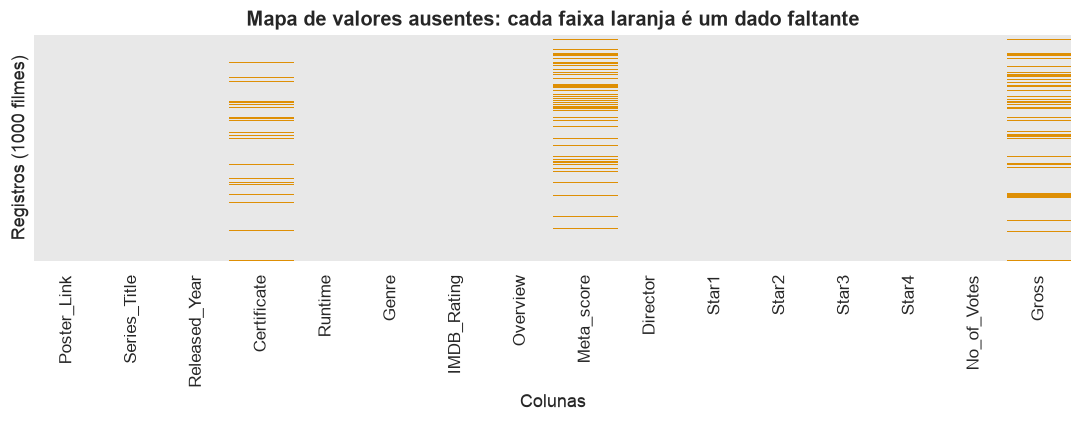

In [5]:
# Panorama de valores ausentes por coluna
diag = pd.DataFrame({
    "tipo":     df.dtypes.astype(str),
    "nulos":    df.isna().sum(),
    "% nulos":  (df.isna().mean() * 100).round(1),
    "distintos": df.nunique(),
})
display(diag)

# Mapa visual dos nulos: cada faixa clara é um dado faltante.
# Um heatmap revela de imediato se os buracos são espalhados ou concentrados.
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, cmap=["#E8E8E8", LARANJA], yticklabels=False, ax=ax)
ax.set_title("Mapa de valores ausentes: cada faixa laranja é um dado faltante")
ax.set_xlabel("Colunas")
ax.set_ylabel("Registros (1000 filmes)")
plt.tight_layout()
plt.show()

**Leitura do mapa:** os nulos se concentram em três colunas: `Certificate` (101),
`Meta_score` (157) e `Gross` (169). Eles estão **espalhados** ao longo dos registros, sem
formar blocos. Isso é uma boa notícia: não há um trecho do arquivo sistematicamente
corrompido, são ausências pontuais.

### 2.2 `Gross`: de texto para número

O valor vem como `"28,341,469"`: uma *string* com vírgulas de milhar. Qualquer conta
aritmética com isso falha. A conversão remove as vírgulas e transforma em número.

Uso `errors="coerce"` para que valores impossíveis de converter virem `NaN` em vez de
derrubar a execução. Assim eles aparecem no diagnóstico em vez de passarem despercebidos.

Também crio `Gross_M` (em **milhões** de dólares), porque ler `US$ 534,9M` num eixo de
gráfico é muito mais fácil do que `534858444`.

In [6]:
print("ANTES :", df["Gross"].dropna().head(3).tolist(), "→ tipo:", df["Gross"].dtype)

df["Gross_num"] = pd.to_numeric(df["Gross"].str.replace(",", "", regex=False), errors="coerce")
df["Gross_M"]   = df["Gross_num"] / 1e6   # em milhões de US$

print("DEPOIS:", df["Gross_num"].dropna().head(3).tolist(), "→ tipo:", df["Gross_num"].dtype)
print(f"\nNulos em Gross: {df['Gross_num'].isna().sum()} de {len(df)} "
      f"({df['Gross_num'].isna().mean()*100:.1f}%)")
# Em milhões o menor valor arredonda para 0.00 e parece bilheteria zerada.
# Imprimo os extremos em dólares para deixar claro que o mínimo não é zero.
menor, maior = df.loc[df["Gross_num"].idxmin()], df.loc[df["Gross_num"].idxmax()]
fmt = lambda v: f"{v:,.0f}".replace(",", ".")   # separador de milhar em pt-BR
print(f"Menor bilheteria: US$ {fmt(menor['Gross_num'])} ({menor['Series_Title']})")
print(f"Maior bilheteria: US$ {fmt(maior['Gross_num'])} ({maior['Series_Title']})")

ANTES : ['28,341,469', '134,966,411', '534,858,444'] → tipo: object
DEPOIS: [28341469.0, 134966411.0, 534858444.0] → tipo: float64

Nulos em Gross: 169 de 1000 (16.9%)
Menor bilheteria: US$ 1.305 (Adams æbler)
Maior bilheteria: US$ 936.662.225 (Star Wars: Episode VII - The Force Awakens)


In [7]:
# ✅ Verificação da ressalva do dicionário: Gross é bilheteria doméstica (EUA/Canadá)?
# Se fosse mundial, Titanic passaria de US$ 2 bilhões.
checagem = df[df["Series_Title"].isin(["Titanic", "Avatar", "The Dark Knight"])]
display(checagem[["Series_Title", "Released_Year", "Gross_M"]]
        .rename(columns={"Gross_M": "Gross (US$ M)"}))
print("Titanic com ~US$ 659M (e não ~US$ 2.200M mundiais) confirma: o dado é doméstico.")

,Series_Title,Released_Year,Gross (US$ M)
2,The Dark Knight,2008,534.858444
623,Avatar,2009,760.507625
652,Titanic,1997,659.325379


Titanic com ~US$ 659M (e não ~US$ 2.200M mundiais) confirma: o dado é doméstico.


### 2.3 `Runtime`: removendo o sufixo " min"

Mesmo problema, solução mais simples: o texto `"142 min"` vira o inteiro `142`.
Confirmo antes que **todas** as linhas seguem esse formato, para não converter às cegas.

In [8]:
# Toda linha termina em " min"? Se sim, a conversão é segura.
formato_ok = df["Runtime"].str.endswith(" min").all()
print(f"Todas as linhas no formato 'N min'? {formato_ok}")

df["Runtime_min"] = df["Runtime"].str.replace(" min", "", regex=False).astype(int)

print(f"\nANTES : {df['Runtime'].head(3).tolist()}")
print(f"DEPOIS: {df['Runtime_min'].head(3).tolist()}")
print(f"\nDuração: mín {df['Runtime_min'].min()} min | "
      f"mediana {df['Runtime_min'].median():.0f} min | máx {df['Runtime_min'].max()} min")

Todas as linhas no formato 'N min'? True

ANTES : ['142 min', '175 min', '152 min']
DEPOIS: [142, 175, 152]

Duração: mín 45 min | mediana 119 min | máx 321 min


### 2.4 `Released_Year`: caçando o valor corrompido

Esta coluna deveria ter só anos de 4 dígitos, mas veio como texto, sinal clássico de que
**algum valor não é um ano**. Em vez de tentar `astype(int)` e torcer, primeiro localizo
os infratores com uma expressão regular.

In [9]:
# Quais valores NÃO são exatamente 4 dígitos?
suspeitos = df[~df["Released_Year"].astype(str).str.fullmatch(r"\d{4}")]
print(f"Linhas com ano inválido: {len(suspeitos)}")
display(suspeitos[["Series_Title", "Released_Year", "Director", "Runtime"]])

Linhas com ano inválido: 1


,Series_Title,Released_Year,Director,Runtime
966,Apollo 13,PG,Ron Howard,140 min


Uma única linha: **Apollo 13** ficou com `"PG"` no lugar do ano. O valor da coluna
`Certificate` claramente vazou para cá durante a coleta dos dados.

Como é **um** registro e o filme é conhecido, a correção certa é **consertar** (Apollo 13
é de 1995), e não descartar. Apagar a linha jogaria fora 15 informações válidas por causa
de 1 errada.

In [10]:
df.loc[df["Series_Title"] == "Apollo 13", "Released_Year"] = "1995"

df["Ano"] = df["Released_Year"].astype(int)
df["Decada"] = (df["Ano"] // 10) * 10      # 1994 → 1990; usada para comparações justas

print("Correção aplicada:")
display(df.loc[df["Series_Title"] == "Apollo 13", ["Series_Title", "Ano", "Certificate"]])
print(f"Período coberto: {df['Ano'].min()} a {df['Ano'].max()}")

Correção aplicada:


,Series_Title,Ano,Certificate
966,Apollo 13,1995,U


Período coberto: 1920 a 2020


### 2.5 Duplicatas: a armadilha que quase engoliu um filme

O reflexo automático seria rodar `drop_duplicates()` no título. Vamos olhar antes de agir.

In [11]:
dups = df[df["Series_Title"].duplicated(keep=False)]
display(dups[["Series_Title", "Ano", "Director", "Genre", "Gross_M"]])

,Series_Title,Ano,Director,Genre,Gross_M
87,Drishyam,2013,Jeethu Joseph,"Crime, Drama, Thriller",NaN
136,Drishyam,2015,Nishikant Kamat,"Crime, Drama, Mystery",0.739478


> ### ⚠️ Lição de limpeza: título repetido ≠ registro duplicado
>
> `Drishyam` aparece duas vezes, mas são **dois filmes diferentes**: o original malaiala
> de 2013 (dir. Jeethu Joseph) e o remake hindi de 2015 (dir. Nishikant Kamat). Ano,
> diretor e bilheteria são distintos.
>
> Um `drop_duplicates(subset="Series_Title")` teria **apagado um filme legítimo** e
> ninguém perceberia. Por isso: nenhuma linha é removida aqui.

In [12]:
# Duplicata real seria a linha INTEIRA repetida. Existe alguma?
print(f"Linhas 100% idênticas: {df.duplicated().sum()}  →  nenhuma remoção necessária.")

Linhas 100% idênticas: 0  →  nenhuma remoção necessária.


### 2.6 `Certificate`: três sistemas de classificação misturados

Aqui está a inconsistência mais séria do dataset. As 16 categorias vêm de sistemas
diferentes e coexistem sem padronização.

In [13]:
display(df["Certificate"].value_counts().to_frame("qtd"))

,qtd
Certificate,
U,234
A,197
UA,175
R,146
PG-13,43
PG,37
Passed,34
G,12
Approved,11


Repare na bagunça:

- **Sistema indiano:** `U` (livre), `UA` (supervisão), `A` (adulto), e ainda `U/A`, que é
  literalmente `UA` escrito de outro jeito;
- **Sistema americano:** `G`, `PG`, `PG-13`, `R`, e `GP` (nome antigo do `PG`, usado nos anos 1970);
- **Sistema de TV:** `TV-PG`, `TV-14`, `TV-MA`;
- **Códigos pré-1968:** `Passed` e `Approved` significavam apenas "aprovado pela censura",
  sem indicar faixa etária;
- **Fora dos três sistemas:** `16` (idade mínima, formato usado em vários países europeus)
  e `Unrated` (nunca submetido à classificação).

Comparar `U` com `G` como se fossem categorias distintas seria um erro: são a mesma coisa
em países diferentes. A solução é agrupar pelo que de fato interessa à nossa pergunta,
**o quão amplo é o público que pode assistir**:

In [14]:
# Agrupamento por AMPLITUDE DE PÚBLICO (não por país de origem da classificação)
MAPA_CERT = {
    "U": "Livre", "G": "Livre",                                     # todas as idades
    "UA": "Supervisão", "U/A": "Supervisão", "PG": "Supervisão",    # com acompanhamento
    "GP": "Supervisão", "PG-13": "Supervisão", "TV-PG": "Supervisão",
    "TV-14": "Supervisão",
    "A": "Adulto", "R": "Adulto", "TV-MA": "Adulto",                # público restrito
    "16": "Adulto",   # "16" barra quem tem menos de 16: é restrição, não supervisão
    "Passed": "Antigo/Sem faixa", "Approved": "Antigo/Sem faixa",   # pré-1968
    "Unrated": "Antigo/Sem faixa",
}
df["Cert_grupo"] = df["Certificate"].map(MAPA_CERT).fillna("Sem info")

print(f"De {df['Certificate'].nunique()} categorias cruas para "
      f"{df['Cert_grupo'].nunique()} grupos interpretáveis:\n")
display(df["Cert_grupo"].value_counts().to_frame("qtd"))

De 16 categorias cruas para 5 grupos interpretáveis:



,qtd
Cert_grupo,
Adulto,345
Supervisão,262
Livre,246
Sem info,101
Antigo/Sem faixa,46


### 2.7 `Genre`: um campo, vários valores

`"Action, Crime, Drama"` guarda **três** gêneros numa célula só. Enquanto estiver assim,
`value_counts()` conta a combinação inteira como se fosse um gênero único, e existem 202
combinações diferentes, o que não diz nada.

A solução é `split` + `explode`: uma linha por par (filme, gênero). Isso vira uma tabela
**auxiliar**: o `df` principal continua com um filme por linha, porque duplicar filmes
lá dentro inflaria qualquer média que calculássemos depois.

In [15]:
df["Genero_lista"] = df["Genre"].str.split(", ")

# Tabela auxiliar: uma linha por (filme, gênero)
df_gen = df.explode("Genero_lista").rename(columns={"Genero_lista": "Genero"})
df_gen["Genero"] = df_gen["Genero"].str.strip()

print(f"df principal : {len(df)} linhas (1 filme por linha)")
print(f"df_gen (aux) : {len(df_gen)} linhas (1 par filme-gênero)")
print(f"Gêneros únicos: {df_gen['Genero'].nunique()}")
print(f"Média de gêneros por filme: {len(df_gen)/len(df):.2f}")

df principal : 1000 linhas (1 filme por linha)
df_gen (aux) : 2541 linhas (1 par filme-gênero)
Gêneros únicos: 21
Média de gêneros por filme: 2.54


### 2.8 Balanço da limpeza

O que mudou entre o arquivo cru e a base pronta para análise:

In [16]:
balanco = pd.DataFrame([
    ["Released_Year", "texto ('PG' em 1 linha)", "Ano: inteiro (corrigido)"],
    ["Runtime",       "texto ('142 min')",       "Runtime_min: inteiro"],
    ["Gross",         "texto ('28,341,469')",    "Gross_num / Gross_M: numérico"],
    ["Certificate",   "16 categorias, 3 sistemas", "Cert_grupo: 5 grupos"],
    ["Genre",         "multivalorado, 202 combos", "df_gen: 1 linha por gênero"],
    ["Decada",        "não existia",             "derivada do Ano (inteiro)"],
], columns=["Coluna", "Antes", "Depois"])
display(balanco)

print(f"Linhas preservadas: {len(df)} de {len(df_bruto)} (nenhuma descartada)")
print(f"Filmes com bilheteria conhecida: {df['Gross_M'].notna().sum()} "
      f"({df['Gross_M'].notna().mean()*100:.1f}%), a base das análises de bilheteria.")

,Coluna,Antes,Depois
0,Released_Year,texto ('PG' em 1 linha),Ano: inteiro (corrigido)
1,Runtime,texto ('142 min'),Runtime_min: inteiro
2,Gross,"texto ('28,341,469')",Gross_num / Gross_M: numérico
3,Certificate,"16 categorias, 3 sistemas",Cert_grupo: 5 grupos
4,Genre,"multivalorado, 202 combos",df_gen: 1 linha por gênero
5,Decada,não existia,derivada do Ano (inteiro)


Linhas preservadas: 1000 de 1000 (nenhuma descartada)
Filmes com bilheteria conhecida: 831 (83.1%), a base das análises de bilheteria.


## 3. 📊 Análise exploratória

Com os dados limpos, começa o reconhecimento do terreno: como cada variável se distribui,
como elas se relacionam e o que mudou ao longo do tempo. Ainda não estamos respondendo a
pergunta central: estamos aprendendo a forma dos dados para não tirar conclusões erradas
depois.

In [17]:
# Resumo estatístico das variáveis numéricas relevantes
df[["IMDB_Rating", "Meta_score", "Runtime_min", "No_of_Votes", "Gross_M", "Ano"]].describe().round(2)

,IMDB_Rating,Meta_score,Runtime_min,No_of_Votes,Gross_M,Ano
count,1000.00,843.00,1000.00,1000.00,831.00,1000.00
mean,7.95,77.97,122.89,273692.91,68.03,1991.22
std,0.28,12.38,28.09,327372.70,109.75,23.29
min,7.60,28.00,45.00,25088.00,0.00,1920.00
25%,7.70,70.00,103.00,55526.25,3.25,1976.00
50%,7.90,79.00,119.00,138548.50,23.53,1999.00
75%,8.10,87.00,137.00,374161.25,80.75,2009.00
max,9.30,100.00,321.00,2343110.00,936.66,2020.00


### 3.1 Como as duas variáveis centrais se distribuem

Nota e bilheteria têm formatos radicalmente diferentes, e entender isso é o que justifica
uma decisão técnica importante mais adiante.

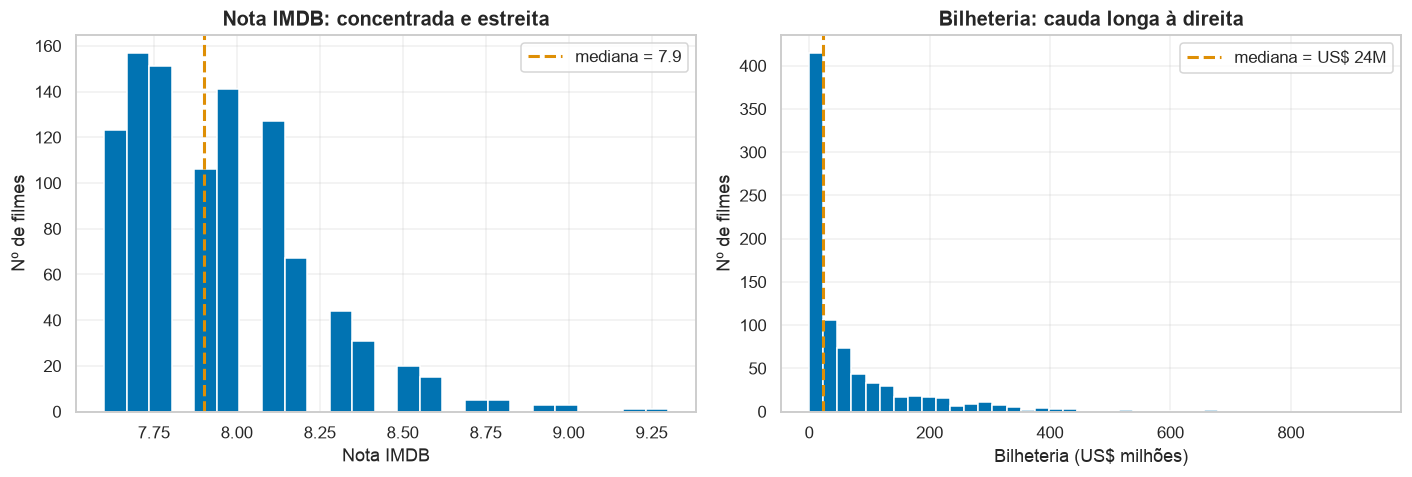

Nota IMDB   → amplitude de apenas 1.7 ponto
Bilheteria  → o maior faturamento é 40x a mediana


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Nota IMDB: distribuição estreita, típica de uma amostra já filtrada por qualidade
axes[0].hist(df["IMDB_Rating"], bins=25, color=AZUL, edgecolor="white")
axes[0].axvline(df["IMDB_Rating"].median(), color=LARANJA, linestyle="--", linewidth=2,
                label=f"mediana = {df['IMDB_Rating'].median():.1f}")
axes[0].set_title("Nota IMDB: concentrada e estreita")
axes[0].set_xlabel("Nota IMDB"); axes[0].set_ylabel("Nº de filmes")
axes[0].legend()

# Bilheteria: fortemente assimétrica à direita (poucos gigantes, muitos pequenos)
axes[1].hist(df["Gross_M"].dropna(), bins=40, color=AZUL, edgecolor="white")
axes[1].axvline(df["Gross_M"].median(), color=LARANJA, linestyle="--", linewidth=2,
                label=f"mediana = US$ {df['Gross_M'].median():.0f}M")
axes[1].set_title("Bilheteria: cauda longa à direita")
axes[1].set_xlabel("Bilheteria (US$ milhões)"); axes[1].set_ylabel("Nº de filmes")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Nota IMDB   → amplitude de apenas {df['IMDB_Rating'].max() - df['IMDB_Rating'].min():.1f} ponto")
print(f"Bilheteria  → o maior faturamento é {df['Gross_M'].max()/df['Gross_M'].median():.0f}x a mediana")

**Duas leituras importantes:**

1. **A nota é comprimida.** Todos os 1000 filmes ficam entre 7,6 e 9,3, menos de 2 pontos
   separando o pior do melhor. É o viés de seleção do dataset aparecendo na prática: com
   tão pouca variação, a nota tem pouquíssimo poder para explicar qualquer coisa.
2. **A bilheteria é assimétrica.** A maioria se aglomera perto de zero e uns poucos
   gigantes esticam a cauda. Numa distribuição assim, a **média engana** (é puxada pelos
   extremos). Por isso usarei a **mediana** em todas as comparações, e **escala
   logarítmica** nos gráficos de bilheteria.

### 3.2 Quais gêneros dominam o catálogo?

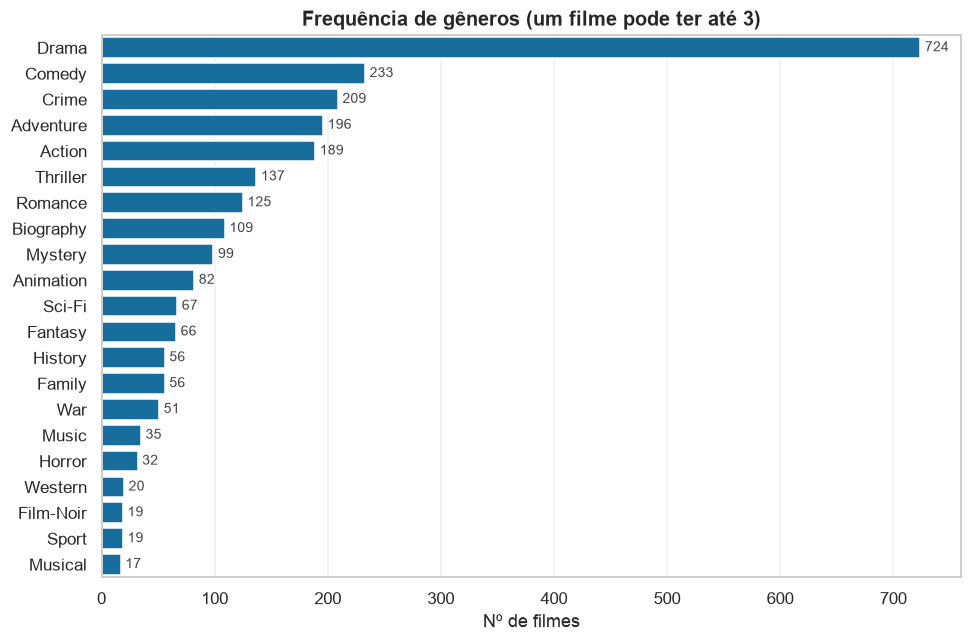

Drama aparece em 724 filmes (72% do catálogo).


In [19]:
ordem = df_gen["Genero"].value_counts().index

fig, ax = plt.subplots(figsize=(9, 6))
sns.countplot(data=df_gen, y="Genero", order=ordem, color=AZUL, ax=ax)
ax.set_title("Frequência de gêneros (um filme pode ter até 3)")
ax.set_xlabel("Nº de filmes"); ax.set_ylabel("")

# Rótulo direto no fim de cada barra: dispensa o leitor de mirar no eixo
for p in ax.patches:
    ax.text(p.get_width() + 4, p.get_y() + p.get_height()/2,
            f"{int(p.get_width())}", va="center", fontsize=9, color="#444")

plt.tight_layout()
plt.show()

print(f"Drama aparece em {(df_gen['Genero']=='Drama').sum()} filmes "
      f"({(df_gen['Genero']=='Drama').sum()/len(df)*100:.0f}% do catálogo).")

`Drama` está em **72%** dos títulos (724 filmes), o gênero preferido da crítica. Guarde essa
informação: ela vai colidir de frente com os dados de bilheteria na Seção 4.

### 3.3 A classificação indicativa influencia a nota?

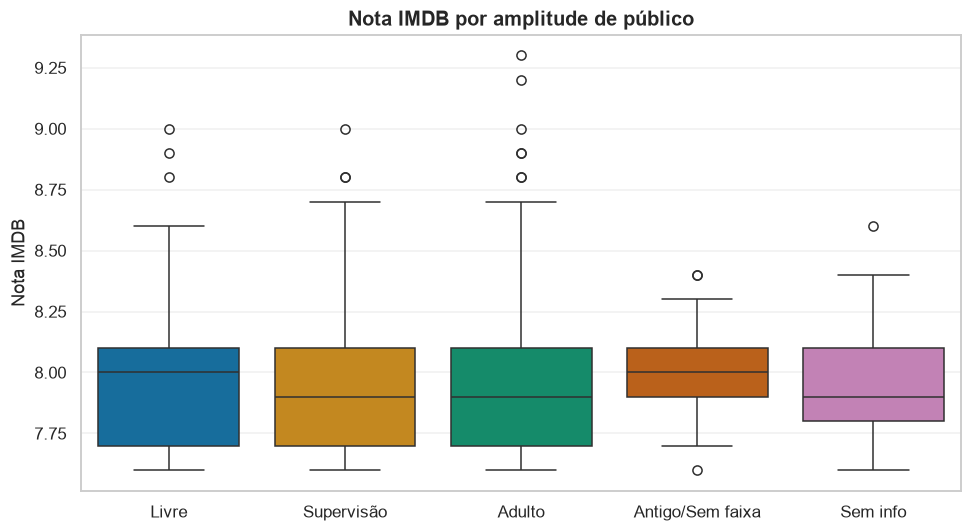

,filmes,nota mediana
Cert_grupo,,
Adulto,345,7.9
Antigo/Sem faixa,46,8.0
Livre,246,8.0
Sem info,101,7.9
Supervisão,262,7.9


In [20]:
ordem_cert = ["Livre", "Supervisão", "Adulto", "Antigo/Sem faixa", "Sem info"]
ordem_cert = [c for c in ordem_cert if c in df["Cert_grupo"].unique()]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Cert_grupo", y="IMDB_Rating", order=ordem_cert,
            hue="Cert_grupo", hue_order=ordem_cert, legend=False, ax=ax)
ax.set_title("Nota IMDB por amplitude de público")
ax.set_xlabel(""); ax.set_ylabel("Nota IMDB")
plt.tight_layout()
plt.show()

display(df.groupby("Cert_grupo")["IMDB_Rating"].agg(["count", "median"]).round(2)
          .rename(columns={"count": "filmes", "median": "nota mediana"}))

As caixas estão praticamente na mesma altura: **a classificação indicativa não prevê a
nota**. Filmes livres e adultos são igualmente bem avaliados. Isso torna ainda mais
interessante o que veremos adiante, porque em **bilheteria** essa mesma variável vai
fazer uma diferença enorme.

### 3.4 O que mudou ao longo das décadas

Duas medidas em escalas totalmente diferentes (contagem de filmes e dólares) exigem
**dois gráficos empilhados** compartilhando o eixo do tempo, e nunca dois eixos Y no
mesmo gráfico, recurso que distorce a comparação e sugere relações que não existem.

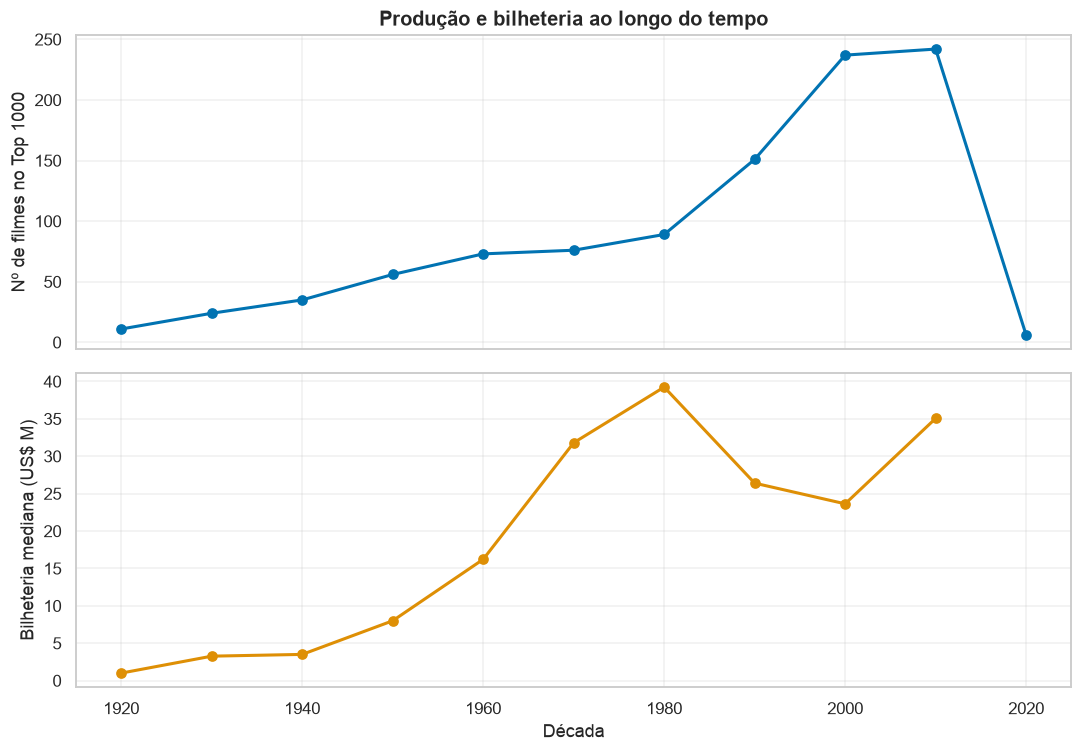

,Decada,filmes,bilheteria_med
0,1920,11,1.0
1,1930,24,3.3
2,1940,35,3.5
3,1950,56,8.0
4,1960,73,16.2
5,1970,76,31.8
6,1980,89,39.2
7,1990,151,26.4
8,2000,237,23.6
9,2010,242,35.1


In [21]:
por_dec = df.groupby("Decada").agg(filmes=("Series_Title", "size"),
                                   bilheteria_med=("Gross_M", "median")).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(por_dec["Decada"], por_dec["filmes"], marker="o", color=AZUL, linewidth=2)
axes[0].set_title("Produção e bilheteria ao longo do tempo")
axes[0].set_ylabel("Nº de filmes no Top 1000")
axes[0].grid(alpha=0.3)

axes[1].plot(por_dec["Decada"], por_dec["bilheteria_med"], marker="o", color=LARANJA, linewidth=2)
axes[1].set_ylabel("Bilheteria mediana (US$ M)")
axes[1].set_xlabel("Década")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
display(por_dec.round(1))

O painel de cima mostra um **viés de recência** claro: 2000 e 2010 concentram quase metade
do catálogo. O IMDb é votado por usuários vivos hoje, que naturalmente assistiram mais
filmes recentes.

O painel de baixo é mais traiçoeiro. A bilheteria mediana sobe até os anos 1980 e depois
**cai**, o que não significa que filmes passaram a faturar menos. São dois efeitos
somados: (a) os valores são **nominais**, sem correção de inflação; e (b) com muito mais
filmes entrando por década recente, entram junto muitos títulos de bilheteria modesta que
puxam a mediana para baixo.

> 🔑 **É exatamente por isso que "campeão de bilheteria" será definido *dentro de cada
> década*** (Seção 5). Comparar um filme de 1970 com um de 2015 em dólares brutos não é
> uma comparação, e sim um erro.

> ⚠️ **Cuidado com a ponta direita do gráfico:** a queda vertical em 2020 **não** é uma
> queda de produção. A década de 2020 está representada por apenas 6 filmes porque o
> dataset foi coletado em 2020, ou seja, é uma década incompleta.
>
> A ausência de bilheteria mediana no painel de baixo tem **outra** causa, e não a mesma:
> os seis filmes de 2020 (*Soul*, *Hamilton*, *Druk*, *Dil Bechara*, *Soorarai Pottru* e
> *The Trial of the Chicago 7*) estão **todos sem `Gross`**, ou seja, não há um único
> valor para a mediana calcular. Uma década incompleta teria mediana normalmente; esta
> não tem porque o dado de bilheteria não existe para nenhum desses seis filmes.
>
> Ler essa ponta como tendência, em qualquer um dos dois painéis, seria um erro.

### 3.5 Matriz de correlação: o primeiro sinal da resposta

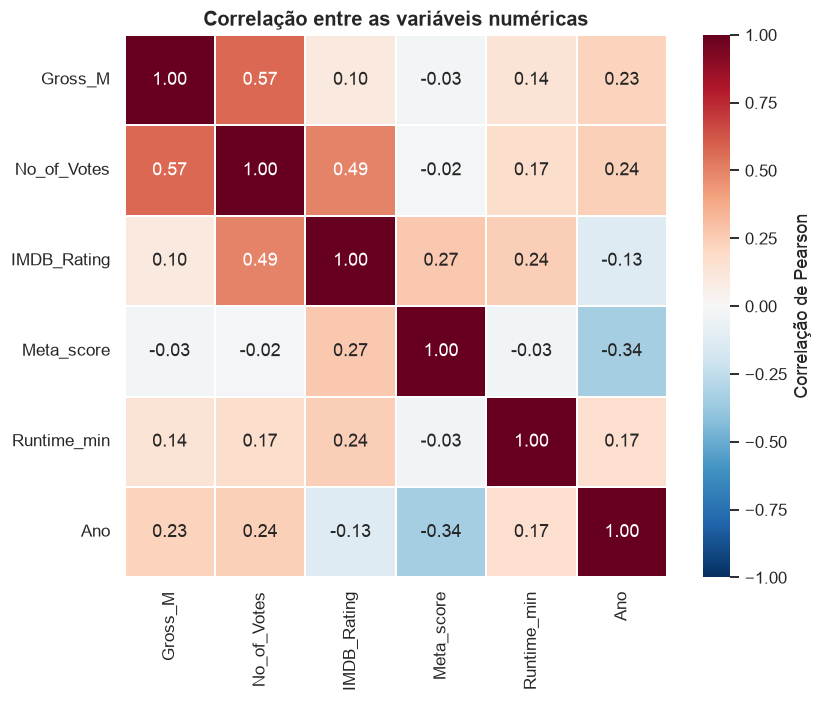

Correlação de cada variável com a BILHETERIA:
No_of_Votes    0.574
Ano            0.233
Runtime_min    0.140
IMDB_Rating    0.096
Meta_score    -0.031


In [22]:
num = ["Gross_M", "No_of_Votes", "IMDB_Rating", "Meta_score", "Runtime_min", "Ano"]
corr = df[num].corr()

# Correlação vai de -1 a +1 com o ZERO como ponto neutro: isso pede uma paleta
# DIVERGENTE centrada em 0 (center=0), e não uma sequencial. Assim a ausência de
# relação aparece como branco, e o sinal (+/-) fica legível de imediato.
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor="white",
            cbar_kws={"label": "Correlação de Pearson"}, ax=ax)
ax.set_title("Correlação entre as variáveis numéricas")
plt.tight_layout()
plt.show()

print("Correlação de cada variável com a BILHETERIA:")
print(corr["Gross_M"].drop("Gross_M").sort_values(ascending=False).round(3).to_string())

> ### 🔍 O achado central já aparece aqui
>
> | Variável | Correlação com bilheteria |
> |---|---|
> | **Nº de votos** | **+0,57** ← forte |
> | Ano | +0,23 |
> | Duração | +0,14 |
> | **Nota IMDB** | **+0,10** ← quase nada |
> | **Meta_score (crítica)** | **−0,03** ← nada |
>
> Quem tem relação com bilheteria é **quantas pessoas viram** o filme, não **quão bom**
> ele é. As notas, tanto de público quanto de crítica, estão essencialmente descorrelacionadas do
> faturamento. As próximas seções vão testar esse sinal a fundo.

## 4. 📈 Visualizações que contam a história

Os três gráficos desta seção, mais a verificação numérica de 4.2, são o coração do
trabalho. Cada bloco responde a uma pergunta específica, e juntos formam o argumento
completo.

### 4.1 A relação que existe: alcance × bilheteria

Como ambas as variáveis são fortemente assimétricas, ambos os eixos usam **escala
logarítmica**. Isso não é um truque estético: em escala log, uma relação proporcional
(*"cada vez que os votos dobram, a bilheteria cresce um fator fixo"*) aparece como uma
**reta**, e é justamente esse tipo de relação que esperamos aqui.

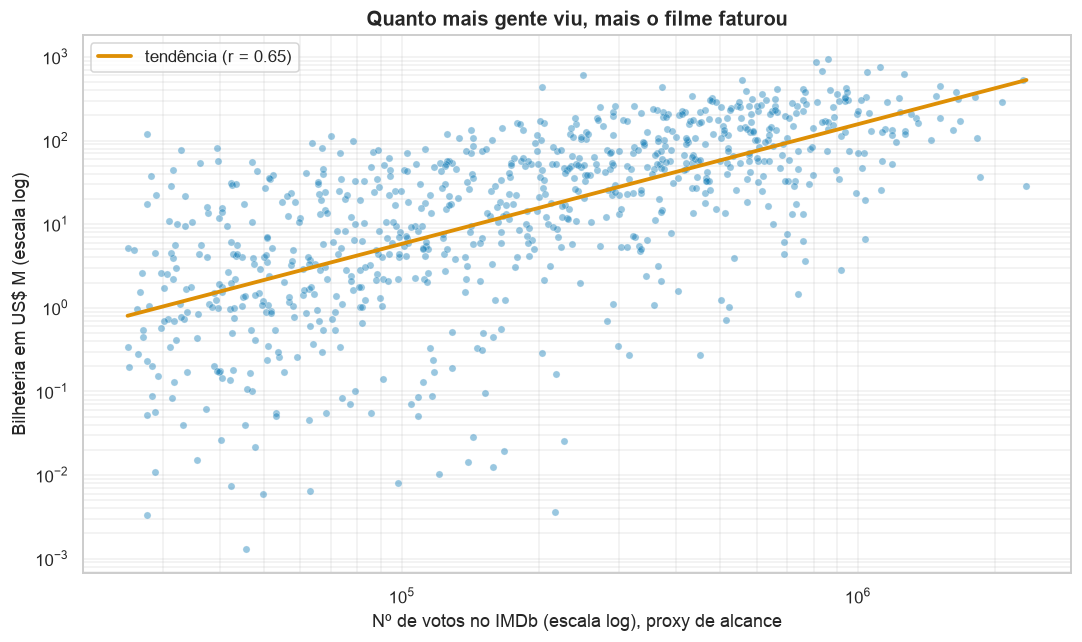

Correlação log-log entre votos e bilheteria: r = 0.649


In [23]:
d = df.dropna(subset=["Gross_M"]).copy()
log_votos = np.log10(d["No_of_Votes"])
log_gross = np.log10(d["Gross_num"])

# Reta de tendência ajustada por mínimos quadrados no espaço log-log
coef = np.polyfit(log_votos, log_gross, 1)
r_loglog = np.corrcoef(log_votos, log_gross)[0, 1]
x_linha = np.linspace(log_votos.min(), log_votos.max(), 100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(d["No_of_Votes"], d["Gross_M"], alpha=0.4, s=22, color=AZUL,
           edgecolor="white", linewidth=0.4)
ax.plot(10**x_linha, (10**np.polyval(coef, x_linha)) / 1e6,
        color=LARANJA, linewidth=2.5, label=f"tendência (r = {r_loglog:.2f})")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Quanto mais gente viu, mais o filme faturou")
ax.set_xlabel("Nº de votos no IMDb (escala log), proxy de alcance")
ax.set_ylabel("Bilheteria em US$ M (escala log)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(f"Correlação log-log entre votos e bilheteria: r = {r_loglog:.3f}")

**r = 0,65 em escala log-log**, uma relação forte e visualmente inequívoca. O alcance
explica boa parte da bilheteria.

Agora o teste decisivo: a **qualidade** faz o mesmo?

### 4.2 A relação que NÃO existe: qualidade × bilheteria

Mesmos filmes, mesma bilheteria em escala log. Troco apenas a variável explicativa: em vez
do alcance (votos), as duas medidas de **qualidade**. Se qualidade movesse a bilheteria, a
correlação deveria se manter alta. Três números resolvem a questão, sem precisar de gráfico.

In [24]:
# Correlação de cada variável com a bilheteria (sempre em log, como no gráfico 4.1).
# Votos entram em log-log; as notas já vivem em escala limitada e entram como estão.
comparacoes = [("No_of_Votes", "Nº de votos (alcance)",   True),
               ("IMDB_Rating", "Nota IMDB (público)",     False),
               ("Meta_score",  "Meta_score (crítica)",    False)]

linhas = []
for var, rotulo, em_log in comparacoes:
    sub = d.dropna(subset=[var])
    x = np.log10(sub[var]) if em_log else sub[var]
    r = np.corrcoef(x, np.log10(sub["Gross_num"]))[0, 1]
    linhas.append([rotulo, f"{r:+.3f}", len(sub)])

display(pd.DataFrame(linhas, columns=["Variável", "r com a bilheteria (log)", "filmes"]))

print("O alcance explica. As duas notas, nenhuma das duas, explicam.")

,Variável,r com a bilheteria (log),filmes
0,Nº de votos (alcance),+0.649,831
1,Nota IMDB (público),-0.004,831
2,Meta_score (crítica),-0.046,750


O alcance explica. As duas notas, nenhuma das duas, explicam.


> ### 💥 O contraste não podia ser mais limpo
>
> O alcance dá **+0,649**. As duas medidas de qualidade dão **−0,004** e **−0,046**, que
> para efeitos práticos é zero: um filme nota 9,0 tem a mesma chance de faturar pouco que
> um filme nota 7,7.
>
> **Entre filmes já aclamados, a qualidade não tem relação com a bilheteria.** E note que
> o Meta_score chega a ser levemente *negativo*: os queridinhos da crítica tendem,
> se algo, a faturar um pouco menos.

### 4.3 Onde está o dinheiro: bilheteria por gênero

Se não é a qualidade, o que é? A primeira pista está na **categoria** do filme.
Uso apenas gêneros com pelo menos 25 filmes, para que as medianas sejam confiáveis.

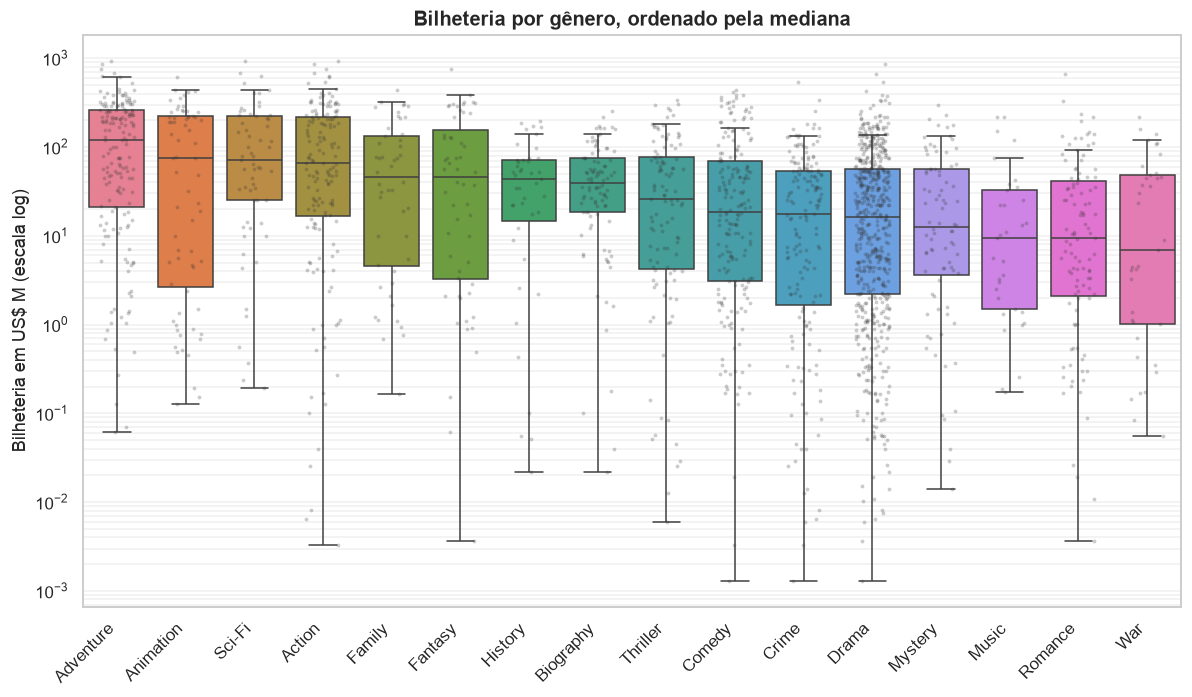

,filmes,mediana
Genero,,
Adventure,170,120.6
Animation,67,75.1
Sci-Fi,61,70.5
Action,156,65.7
Family,48,46.1
Fantasy,56,46.0
History,43,44.0
Biography,96,39.8
Thriller,110,25.8


In [25]:
gen_ok = df_gen.dropna(subset=["Gross_M"])
freq = gen_ok["Genero"].value_counts()
generos_validos = freq[freq >= 25].index
gen_ok = gen_ok[gen_ok["Genero"].isin(generos_validos)]

ordem_gen = gen_ok.groupby("Genero")["Gross_M"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.boxplot(data=gen_ok, x="Genero", y="Gross_M", order=ordem_gen,
            hue="Genero", hue_order=ordem_gen, legend=False, showfliers=False, ax=ax)
sns.stripplot(data=gen_ok, x="Genero", y="Gross_M", order=ordem_gen,
              color="#333333", alpha=0.25, size=2.5, jitter=0.25, ax=ax)

ax.set_yscale("log")
ax.set_title("Bilheteria por gênero, ordenado pela mediana")
ax.set_xlabel(""); ax.set_ylabel("Bilheteria em US$ M (escala log)")
plt.xticks(rotation=45, ha="right")
ax.grid(alpha=0.3, which="both", axis="y")
plt.tight_layout()
plt.show()

tab_gen = (gen_ok.groupby("Genero")["Gross_M"]
           .agg(filmes="size", mediana="median").round(1)
           .sort_values("mediana", ascending=False))
display(tab_gen)

A distância é enorme: **Aventura fatura 7,4× mais que Drama** na mediana
(US$ 120,6M contra US$ 16,2M). E lembre da Seção 3.2: Drama é o gênero **mais comum** do
catálogo, presente em **72%** dos filmes. Ou seja: o gênero que a crítica mais celebra é
justamente um dos que menos faturam.

### 4.4 Diretores: quem entrega bilheteria de forma consistente

Exijo no mínimo **4 filmes** por diretor. Sem esse corte, o ranking premiaria quem teve um
único sucesso de sorte, e a pergunta aqui é sobre **consistência**.

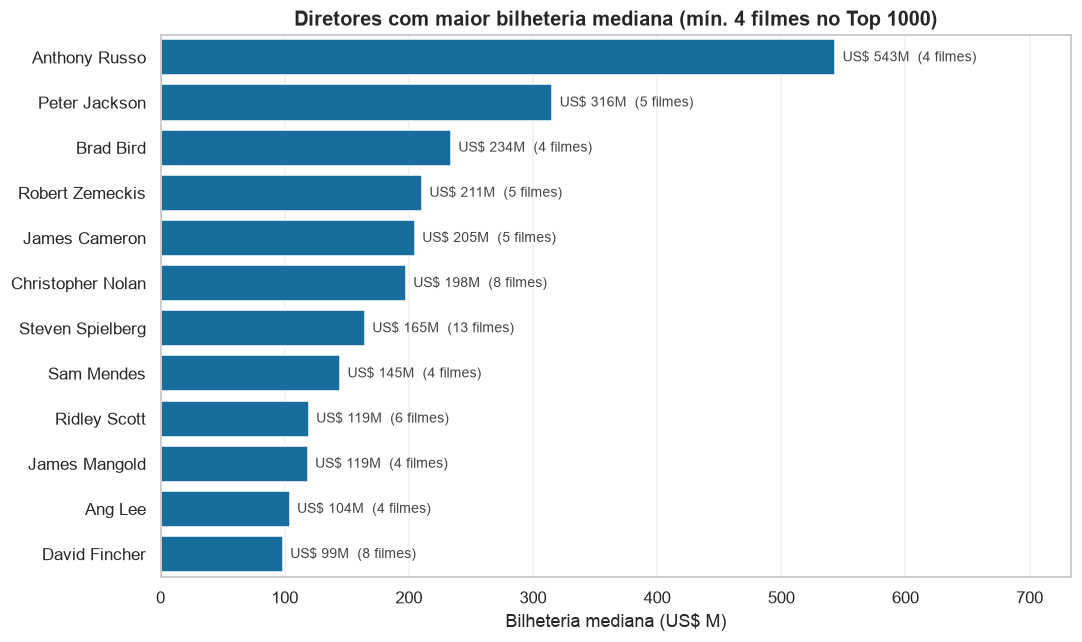

In [26]:
dir_stats = (d.groupby("Director")["Gross_M"]
             .agg(filmes="size", mediana="median")
             .query("filmes >= 4")
             .sort_values("mediana", ascending=False)
             .head(12).reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=dir_stats, y="Director", x="mediana", color=AZUL, ax=ax)
ax.set_title("Diretores com maior bilheteria mediana (mín. 4 filmes no Top 1000)")
ax.set_xlabel("Bilheteria mediana (US$ M)"); ax.set_ylabel("")

for i, row in dir_stats.iterrows():
    ax.text(row["mediana"] + 6, i, f"US$ {row['mediana']:.0f}M  ({row['filmes']} filmes)",
            va="center", fontsize=9, color="#444")
ax.set_xlim(0, dir_stats["mediana"].max() * 1.35)
plt.tight_layout()
plt.show()

O ranking é uma lista de especialistas em **blockbuster de grande escala**: Anthony Russo
(*Vingadores*), Peter Jackson (*O Senhor dos Anéis*), James Cameron, Christopher Nolan,
Spielberg. Nenhum diretor de drama intimista aparece, por mais aclamado que seja. É a
mesma mensagem do gráfico de gêneros, vista por outro ângulo.

## 5. 🔍 Identificação de insights

### 5.1 Definindo "campeão de bilheteria"

Para comparar campeões com o restante, preciso primeiro de uma régua. E ela tem que ser
**justa com o tempo**: como vimos na Seção 3.4, `Gross` é nominal, então US$ 100M em 1975
e em 2015 não são a mesma conquista.

**A régua adotada:** é campeão o filme que está no **top 25% de bilheteria da sua própria
década**. Cada filme compete apenas com seus contemporâneos, e a inflação sai da conta
sem eu precisar de nenhum índice econômico externo.

In [27]:
d = df.dropna(subset=["Gross_M"]).copy()

# O corte é calculado DENTRO de cada década via transform
d["Campeao"] = d.groupby("Decada")["Gross_M"].transform(lambda s: s >= s.quantile(0.75))
d["Grupo"] = np.where(d["Campeao"], "Campeões", "Demais")

print("Limiar de entrada no top 25%, por década:")
display(d.groupby("Decada")["Gross_M"].quantile(0.75).round(1).to_frame("corte (US$ M)"))
print(f"\nCampeões: {d['Campeao'].sum()} filmes | Demais: {(~d['Campeao']).sum()} filmes")

Limiar de entrada no top 25%, por década:


,corte (US$ M)
Decada,
1920,2.3
1930,4.4
1940,7.3
1950,12.9
1960,44.8
1970,73.6
1980,78.8
1990,70.9
2000,85.8



Campeões: 212 filmes | Demais: 619 filmes


### 5.2 O perfil comparativo

Agora a pergunta central em forma de tabela: no que os dois grupos diferem?

In [28]:
perfil = d.groupby("Grupo").agg(
    filmes=("Gross_M", "size"),
    bilheteria_mediana=("Gross_M", "median"),
    votos_medianos=("No_of_Votes", "median"),
    nota_mediana=("IMDB_Rating", "median"),
    meta_mediana=("Meta_score", "median"),
    duracao_mediana=("Runtime_min", "median"),
    ano_mediano=("Ano", "median"),
).round(1).T
display(perfil)

camp, dem = perfil["Campeões"], perfil["Demais"]
print("\nQuantas vezes os campeões superam os demais:")
print(f"  Bilheteria : {camp['bilheteria_mediana']/dem['bilheteria_mediana']:.1f}x")
print(f"  Votos      : {camp['votos_medianos']/dem['votos_medianos']:.1f}x")
print(f"  Nota IMDB  : {camp['nota_mediana']/dem['nota_mediana']:.2f}x  "
      f"(diferença absoluta: {camp['nota_mediana']-dem['nota_mediana']:+.1f} ponto)")
print(f"  Meta_score : {camp['meta_mediana']/dem['meta_mediana']:.2f}x  "
      f"(diferença absoluta: {camp['meta_mediana']-dem['meta_mediana']:+.0f} pontos)")

Grupo,Campeões,Demais
filmes,212.0,619.0
bilheteria_mediana,171.0,9.4
votos_medianos,496825.0,125822.0
nota_mediana,8.0,7.9
meta_mediana,78.0,78.0
duracao_mediana,127.0,119.0
ano_mediano,2000.0,2001.0



Quantas vezes os campeões superam os demais:
  Bilheteria : 18.2x
  Votos      : 3.9x
  Nota IMDB  : 1.01x  (diferença absoluta: +0.1 ponto)
  Meta_score : 1.00x  (diferença absoluta: +0 pontos)


### 5.3 O contraste em um gráfico

As quatro métricas têm escalas incompatíveis (dólares, votos, pontos de nota, minutos).
Colocá-las num eixo só esmagaria as menores. Por isso, **quatro painéis independentes**,
cada um com sua própria escala.

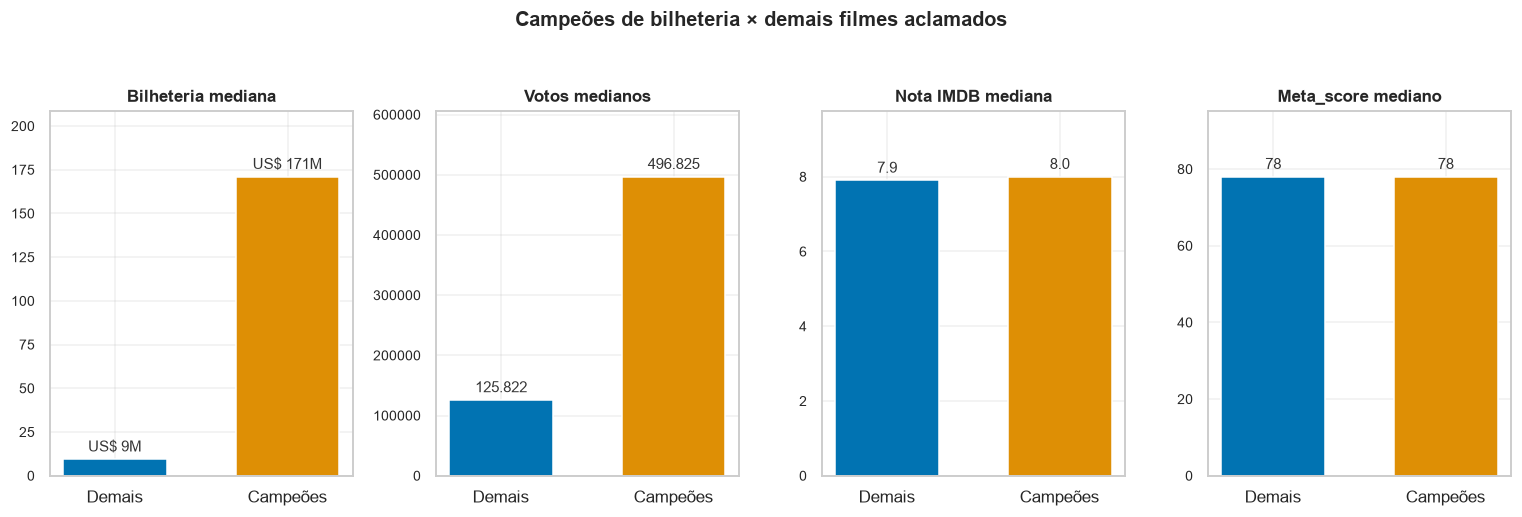

In [29]:
metricas = [("bilheteria_mediana", "Bilheteria mediana", lambda v: f"US$ {v:,.0f}M".replace(",", ".")),
            ("votos_medianos",     "Votos medianos",     lambda v: f"{v:,.0f}".replace(",", ".")),
            ("nota_mediana",       "Nota IMDB mediana",  lambda v: f"{v:.1f}"),
            ("meta_mediana",       "Meta_score mediano", lambda v: f"{v:.0f}")]

fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
for ax, (chave, titulo, formata) in zip(axes, metricas):
    vals = [perfil.loc[chave, "Demais"], perfil.loc[chave, "Campeões"]]
    barras = ax.bar(["Demais", "Campeões"], vals, color=[AZUL, LARANJA], width=0.6)
    ax.set_title(titulo, fontsize=11)
    # Rótulo formatado por métrica: 496.825 é legível, 496825.0 não é
    ax.bar_label(barras, labels=[formata(v) for v in vals], padding=3, fontsize=10, color="#333")
    ax.set_ylim(0, max(vals) * 1.22)
    ax.grid(alpha=0.3, axis="y")
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("Campeões de bilheteria × demais filmes aclamados",
             fontweight="bold", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

> ### 💥 O resultado que responde a pergunta do trabalho
>
> Os dois primeiros painéis têm barras laranja gigantes. Os dois últimos têm barras
> **do mesmo tamanho**.
>
> Campeões faturam **18× mais** e têm **3,9× mais votos**, mas a nota mediana difere em
> **0,1 ponto** (8,0 vs 7,9) e o Meta_score é **idêntico: 78 nos dois grupos**.
>
> A qualidade não separa nada. O alcance separa tudo.

### 5.4 Então o que produz alcance? Gênero e classificação indicativa

Se o alcance é o que importa, a pergunta vira: quais filmes conseguem alcance? Aqui uso a
**taxa de campeões**: que percentual dos filmes de cada categoria chega ao top 25% da sua
década.

Dois recortes, pelo mesmo motivo de sempre (categoria pequena demais gera percentual
instável, e categoria sem significado não responde nada):

- **gêneros com pelo menos 25 filmes**, o que preserva 16 dos 21 gêneros e descarta os 5 mais raros;
- **apenas os três grupos com faixa etária definida**, o que exclui `Sem info` e
  `Antigo/Sem faixa`, isto é, 76 dos 831 filmes com bilheteria conhecida. Não faria sentido
  perguntar a "amplitude de público" de um filme cuja classificação é desconhecida.

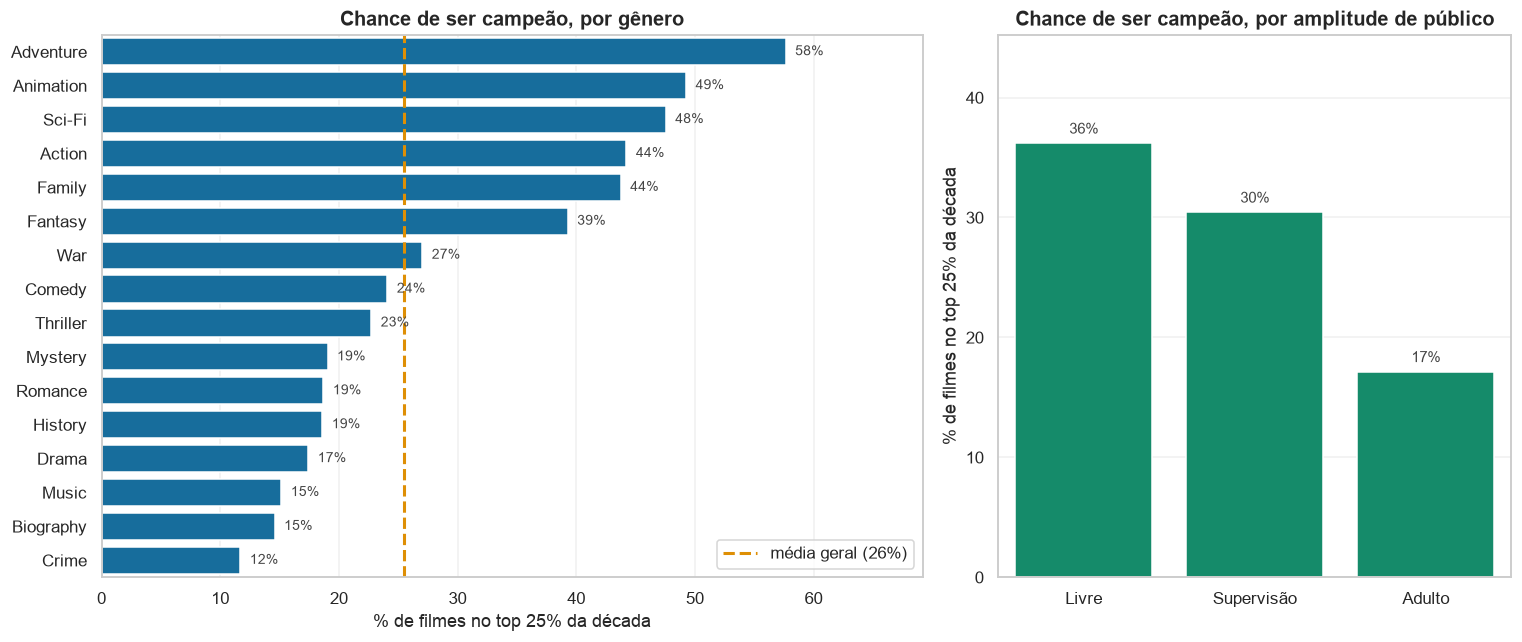

In [30]:
# Taxa de campeões por gênero
g = d.assign(Genero=d["Genre"].str.split(", ")).explode("Genero")
g["Genero"] = g["Genero"].str.strip()
freq_g = g["Genero"].value_counts()
g = g[g["Genero"].isin(freq_g[freq_g >= 25].index)]
taxa_gen = (g.groupby("Genero")["Campeao"].mean() * 100).sort_values(ascending=False)

# Taxa de campeões por classificação indicativa
cert_ok = d[d["Cert_grupo"].isin(["Livre", "Supervisão", "Adulto"])]
taxa_cert = (cert_ok.groupby("Cert_grupo")["Campeao"].mean() * 100
             ).reindex(["Livre", "Supervisão", "Adulto"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.6, 1]})

sns.barplot(x=taxa_gen.values, y=taxa_gen.index, color=AZUL, ax=axes[0])
axes[0].axvline(d["Campeao"].mean()*100, color=LARANJA, linestyle="--", linewidth=2,
                label=f"média geral ({d['Campeao'].mean()*100:.0f}%)")
axes[0].set_title("Chance de ser campeão, por gênero")
axes[0].set_xlabel("% de filmes no top 25% da década"); axes[0].set_ylabel("")
axes[0].legend()
for i, v in enumerate(taxa_gen.values):
    axes[0].text(v + 0.8, i, f"{v:.0f}%", va="center", fontsize=9, color="#444")
axes[0].set_xlim(0, taxa_gen.max() * 1.2)

sns.barplot(x=taxa_cert.index, y=taxa_cert.values, color=VERDE, ax=axes[1])
axes[1].set_title("Chance de ser campeão, por amplitude de público")
axes[1].set_xlabel(""); axes[1].set_ylabel("% de filmes no top 25% da década")
for i, v in enumerate(taxa_cert.values):
    axes[1].text(i, v + 0.8, f"{v:.0f}%", ha="center", fontsize=10, color="#444")
axes[1].set_ylim(0, taxa_cert.max() * 1.25)
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Os dois painéis contam a **mesma** história por caminhos independentes:

- **Por gênero:** Aventura (58%), Animação (49%) e Ficção Científica (48%) são campeões com
  muito mais frequência que Drama (17%), Crime (12%) e Biografia (15%).
- **Por classificação:** filmes **livres** viram campeões em **36%** dos casos, contra
  **17%** dos filmes **adultos**, mais que o dobro.

Aventura, animação e ficção científica com classificação livre são exatamente os filmes
que **uma família inteira pode assistir junta**. Filmes adultos de drama e crime, por
melhores que sejam, endereçam um público estruturalmente menor.

### 5.5 Os cinco insights

**1. Entre filmes aclamados, qualidade não prevê bilheteria.**
A correlação entre nota IMDB e bilheteria (em log) é de **−0,004**, literalmente zero. Com
o Meta_score é **−0,046**. Campeões e demais têm Meta_score mediano **idêntico (78)** e
notas praticamente iguais (8,0 vs 7,9).

**2. O alcance prevê, e prevê forte.**
Votos × bilheteria dão **r = 0,65** em escala log-log. Campeões têm **3,9× mais votos**
(497 mil contra 126 mil na mediana).

**3. Quem define o alcance é a categoria do filme, não seu mérito.**
Aventura fatura **7,4× mais** que Drama na mediana (US$ 120,6M vs US$ 16,2M) e vira campeão
**3,3× mais** vezes (58% vs 17%).

**4. Amplitude de público é vantagem estrutural.**
Filmes de classificação livre são campeões em **36%** dos casos contra **17%** dos adultos.
Toda restrição etária corta uma fatia do público antes mesmo do filme estrear.

**5. O catálogo do IMDb premia o oposto do que a bilheteria premia.**
Drama é o gênero **mais frequente** do Top 1000 (presente em **72%** dos títulos) e um dos que
**menos faturam**. Crítica e bilheteria recompensam coisas diferentes, e este dataset
mostra as duas lógicas convivendo lado a lado.

## 6. 📋 Conclusões e recomendações

### A resposta

> **Entre filmes já aclamados, o que separa os campeões de bilheteria dos demais não é
> serem melhores, e sim serem mais *acessíveis*.**

A qualidade funciona como um **ingresso de entrada**, não como um diferencial. Todo filme
deste dataset já passou pelo filtro de qualidade; a partir daí, o que decide o faturamento
é o **tamanho do público que pode e quer assistir**: gênero de apelo amplo, classificação
sem restrição e alcance de distribuição.

Isso explica a estranheza inicial: não é que qualidade *atrapalhe* bilheteria. É que,
quando **todos** os concorrentes já são bons, a qualidade deixa de ser o critério que
diferencia, e outra variável assume o comando.

### Recomendações

**Para um estúdio que quer maximizar bilheteria**
1. Priorizar **aventura, animação e ficção científica**: 48% a 58% de taxa de campeão contra
   17% de drama.
2. Buscar **classificação livre** sempre que a narrativa permitir: dobra a chance de
   campeão (36% vs 17%).
3. **Não esperar retorno de bilheteria pelo investimento em prestígio crítico**: o
   Meta_score não tem relação com faturamento neste recorte. Prestígio deve ser buscado por
   outros motivos (prêmios, catálogo, retenção em streaming), não como alavanca de bilheteria.
4. Tratar **alcance como o produto real**: número de salas, campanha e janela de estreia
   pesam mais do que o polimento final do roteiro, no que diz respeito a faturamento.

**Para um curador ou plataforma de streaming**
5. **Bilheteria não é sinal de qualidade** aqui, e usá-la para ranquear catálogo enviesaria
   as recomendações para blockbusters e enterraria dramas igualmente bem avaliados.
6. Como nota e classificação indicativa **não** se relacionam (Seção 3.3), dá para montar
   trilhas de alta qualidade para qualquer faixa etária sem sacrificar nota.

### ⚠️ Limitações: o que estes dados ainda NÃO permitem afirmar completamente

Nenhuma conclusão acima vale fora do recorte analisado. Cinco ressalvas honestas:

1. **Viés de seleção (a mais importante).** O dataset só contém filmes bem avaliados.
   Quando digo "qualidade não explica bilheteria", isso vale **entre filmes já aclamados**,
   e não para o cinema em geral. Num conjunto que incluísse filmes ruins, a qualidade
   provavelmente teria, sim, poder explicativo. Este é o limite mais sério do trabalho.

2. **Bilheteria doméstica apenas.** `Gross` cobre EUA/Canadá (verificado na Seção 2.2 com
   o `Titanic`). Filmes de apelo internacional, especialmente o cinema indiano, fortemente
   representado aqui, estão subestimados.

3. **Bruto, não lucro.** Sem a coluna de orçamento, é impossível dizer se um campeão de
   bilheteria deu lucro. Um filme de US$ 200M de bilheteria e US$ 250M de custo é prejuízo,
   e a nossa régua o chamaria de campeão.

4. **Correlação não é causalidade.** Votos e bilheteria se reforçam mutuamente: mais gente
   assiste → mais gente vota, e um filme bem distribuído gera as duas coisas ao mesmo tempo.
   O nº de votos é um **proxy** de alcance, não sua causa.

5. **169 filmes sem bilheteria (16,9%)** ficaram fora das análises de faturamento. Se essa
   ausência não for aleatória (por exemplo, se filmes antigos ou estrangeiros tiverem mais
   chance de não ter o dado), há um viés residual que não conseguimos medir.

### Possíveis próximos passos

- Cruzar com um dataset que traga **orçamento** (ex.: TMDB), trocando bilheteria por **ROI**;
- Corrigir `Gross` pela **inflação** com um índice oficial, permitindo comparação direta
  entre eras;
- Incorporar **bilheteria mundial** para medir o efeito do mercado internacional;
- Contrastar com uma amostra de filmes **mal avaliados**, o único caminho para escapar do
  viés de seleção e testar a hipótese de qualidade de forma justa.

---

*Análise desenvolvida para a disciplina LIA 1 (2026/2) · Matheus Sousa Marinho (202206132)*
*Ferramentas: Python · pandas · NumPy · Matplotlib · Seaborn*